# OGDH Parameter Classification
n=65 (Hand/control=35, OGDH knockdown=30)
Fixes: StratifiedKFold, bootstrap CI, permutation test, consistent CM

In [1]:
# Cell 1 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os
warnings.filterwarnings('ignore')
os.makedirs('./results_ogdh_param', exist_ok=True)

from itertools import permutations
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, permutation_test_score
from sklearn.metrics import (accuracy_score, roc_auc_score, confusion_matrix,
                              roc_curve, auc)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.pipeline import make_pipeline
from scipy.optimize import linear_sum_assignment
from matplotlib.patches import Patch
print('Imports done')

Imports done


In [2]:
# Cell 2 — Load data and feature engineering
df = pd.read_csv('Control_Mutant_Nat_Comm.csv')
df['Target'] = df['Name'].apply(
    lambda x: 0 if 'Hand' in x else 1 if 'OGDH' in x else np.nan)
df.dropna(subset=['Target'], inplace=True)
df.reset_index(drop=True, inplace=True)

raw_feats = ['DD','SD','FS','DI','SI','HP','HR','AI']

# Pairwise derived features
for a,b in permutations(raw_feats, 2):
    df[f'{a}_MINUS_{b}'] = df[a] - df[b]
    df[f'{a}_DIV_{b}']   = df[a] / df[b].replace(0, np.nan)

# Domain-specific features
df['HR_FS_Product'] = df['HR'] * df['FS']
df['DD_SD_Diff']    = df['DD'] - df['SD']

df.replace([np.inf,-np.inf], np.nan, inplace=True)
df.fillna(0, inplace=True)

# Top 5 features from manuscript
top_feats = ['SD','FS','DD','HR_FS_Product','DD_SD_Diff']
X = df[top_feats]
y = df['Target'].astype(int)

all_feat_cols = raw_feats + [c for c in df.columns
                              if '_MINUS_' in c or '_DIV_' in c
                              or c in ['HR_FS_Product','DD_SD_Diff']]

print(f'n={len(df)}')
print(f'Hand (control): {(y==0).sum()}')
print(f'OGDH knockdown: {(y==1).sum()}')
print(f'Features used:  {top_feats}')

n=65
Hand (control): 35
OGDH knockdown: 30
Features used:  ['SD', 'FS', 'DD', 'HR_FS_Product', 'DD_SD_Diff']


In [3]:
# Cell 3 — Bootstrap CI helper
def bootstrap_ci(y_true, y_proba, n_boot=1000, seed=42):
    rng = np.random.default_rng(seed)
    n   = len(y_true)
    accs, aucs = [], []
    for _ in range(n_boot):
        idx  = rng.integers(0, n, size=n)
        yt_b = y_true[idx]
        yp_b = y_proba[idx]
        if len(np.unique(yt_b)) < 2: continue
        accs.append(accuracy_score(yt_b, (yp_b>=0.5).astype(int)))
        fpr_b, tpr_b, _ = roc_curve(yt_b, yp_b)
        aucs.append(auc(fpr_b, tpr_b))
    return ((np.percentile(accs,2.5), np.percentile(accs,97.5)),
            (np.percentile(aucs,2.5), np.percentile(aucs,97.5)))
print('Bootstrap CI helper defined')

Bootstrap CI helper defined


In [4]:
# Cell 4 — Supervised RF with StratifiedKFold
skf      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
mean_fpr = np.linspace(0, 1, 100)
tprs, cm_list = [], []
fold_accs, fold_aucs = [], []
all_y_true, all_y_proba = [], []

for fold,(train_idx,test_idx) in enumerate(skf.split(X,y),1):
    Xtr,Xte = X.iloc[train_idx], X.iloc[test_idx]
    ytr,yte = y.iloc[train_idx], y.iloc[test_idx]
    pipe = make_pipeline(
        StandardScaler(),
        RandomForestClassifier(n_estimators=300, random_state=42))
    pipe.fit(Xtr, ytr)
    ypred  = pipe.predict(Xte)
    yproba = pipe.predict_proba(Xte)[:,1]
    fold_accs.append(accuracy_score(yte, ypred))
    fold_aucs.append(roc_auc_score(yte, yproba))
    cm = confusion_matrix(yte, ypred, labels=[0,1]).astype(float)
    cm_list.append(cm / cm.sum(axis=1, keepdims=True))
    fpr,tpr,_ = roc_curve(yte, yproba)
    tprs.append(np.interp(mean_fpr, fpr, tpr))
    all_y_true.extend(yte)
    all_y_proba.extend(yproba)
    print(f'  Fold {fold}: Acc={fold_accs[-1]:.4f}  AUC={fold_aucs[-1]:.4f}')

avg_cm       = np.mean(cm_list, axis=0)
mean_acc     = np.mean(fold_accs); std_acc  = np.std(fold_accs)
mean_auc     = np.mean(fold_aucs); std_auc  = np.std(fold_aucs)
mean_tpr_arr = np.mean(tprs, axis=0); mean_tpr_arr[-1] = 1.0
std_tpr      = np.std(tprs, axis=0)

ay, ap = np.array(all_y_true), np.array(all_y_proba)
ci_acc, ci_auc = bootstrap_ci(ay, ap)

print(f'\nMean Acc  = {mean_acc:.4f} +/- {std_acc:.4f}')
print(f'Mean AUROC= {mean_auc:.4f} +/- {std_auc:.4f}')
print(f'95%CI Acc  [{ci_acc[0]:.4f}, {ci_acc[1]:.4f}]')
print(f'95%CI AUROC[{ci_auc[0]:.4f}, {ci_auc[1]:.4f}]')

pd.DataFrame({
    'Fold':     list(range(1,6)) + ['Mean','Std'],
    'Accuracy': fold_accs + [mean_acc, std_acc],
    'AUROC':    fold_aucs + [mean_auc, std_auc]
}).to_csv('./results_ogdh_param/kfold_stats_ogdh.csv', index=False)
print('Saved: ./results_ogdh_param/kfold_stats_ogdh.csv')

  Fold 1: Acc=1.0000  AUC=1.0000
  Fold 2: Acc=1.0000  AUC=1.0000
  Fold 3: Acc=0.9231  AUC=1.0000
  Fold 4: Acc=1.0000  AUC=1.0000
  Fold 5: Acc=1.0000  AUC=1.0000

Mean Acc  = 0.9846 +/- 0.0308
Mean AUROC= 1.0000 +/- 0.0000
95%CI Acc  [0.9538, 1.0000]
95%CI AUROC[0.9848, 1.0000]
Saved: ./results_ogdh_param/kfold_stats_ogdh.csv


In [5]:
# Cell 5 — Permutation test
print('Running permutation test (100 permutations)...')
pipe_perm = make_pipeline(StandardScaler(),
                           RandomForestClassifier(n_estimators=100, random_state=42))
score_obs, perm_scores, p_value = permutation_test_score(
    pipe_perm, X, y, scoring='roc_auc',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_permutations=100, random_state=42, n_jobs=-1)
print(f'  Observed AUROC = {score_obs:.4f}')
print(f'  Permuted mean  = {perm_scores.mean():.4f} +/- {perm_scores.std():.4f}')
print(f'  p-value        = {p_value:.4f}')
print(f'  Result is {"SIGNIFICANT" if p_value<0.05 else "NOT SIGNIFICANT"} (p<0.05)')
pd.DataFrame({'observed':[score_obs],'perm_mean':[perm_scores.mean()],'p_value':[p_value]}
             ).to_csv('./results_ogdh_param/permutation_ogdh.csv', index=False)

Running permutation test (100 permutations)...
  Observed AUROC = 1.0000
  Permuted mean  = 0.4919 +/- 0.1082
  p-value        = 0.0099
  Result is SIGNIFICANT (p<0.05)


In [6]:
# Cell 6 — Unsupervised KMeans (10-run stability)
X_scaled = StandardScaler().fit_transform(X)
best_labels, best_acc_km, accs_km = None, 0, []
for seed in range(10):
    km     = KMeans(n_clusters=2, init='k-means++', n_init=10, random_state=seed)
    labels = km.fit_predict(X_scaled)
    cont   = pd.crosstab(y.values, labels)
    ri,ci  = linear_sum_assignment(-cont.values)
    lmap   = dict(zip(ci, ri))
    mapped = np.array([lmap[l] for l in labels])
    acc_km = accuracy_score(y.values, mapped)
    accs_km.append(acc_km)
    if acc_km > best_acc_km:
        best_acc_km = acc_km
        best_labels = mapped.copy()

cm_unsup      = confusion_matrix(y.values, best_labels, labels=[0,1]).astype(float)
cm_unsup_norm = cm_unsup / cm_unsup.sum(axis=1, keepdims=True)
print(f'KMeans Acc = {np.mean(accs_km):.4f} +/- {np.std(accs_km):.4f}')
print(f'Best run   = {best_acc_km:.4f}')

KMeans Acc = 0.9846 +/- 0.0000
Best run   = 0.9846


In [7]:
# Cell 7 — Correlation matrix and feature importance
corr_matrix = df[raw_feats].corr()

rf_all = RandomForestClassifier(n_estimators=500, random_state=42)
rf_all.fit(df[all_feat_cols], y)
imp_series = pd.Series(rf_all.feature_importances_,
                        index=all_feat_cols).sort_values(ascending=False).head(10)

pca       = PCA(n_components=2, random_state=42)
pca_2d    = pca.fit_transform(X_scaled)
explained = pca.explained_variance_ratio_
best_labels_arr = np.array(best_labels)
print('Correlation and PCA computed')

Correlation and PCA computed


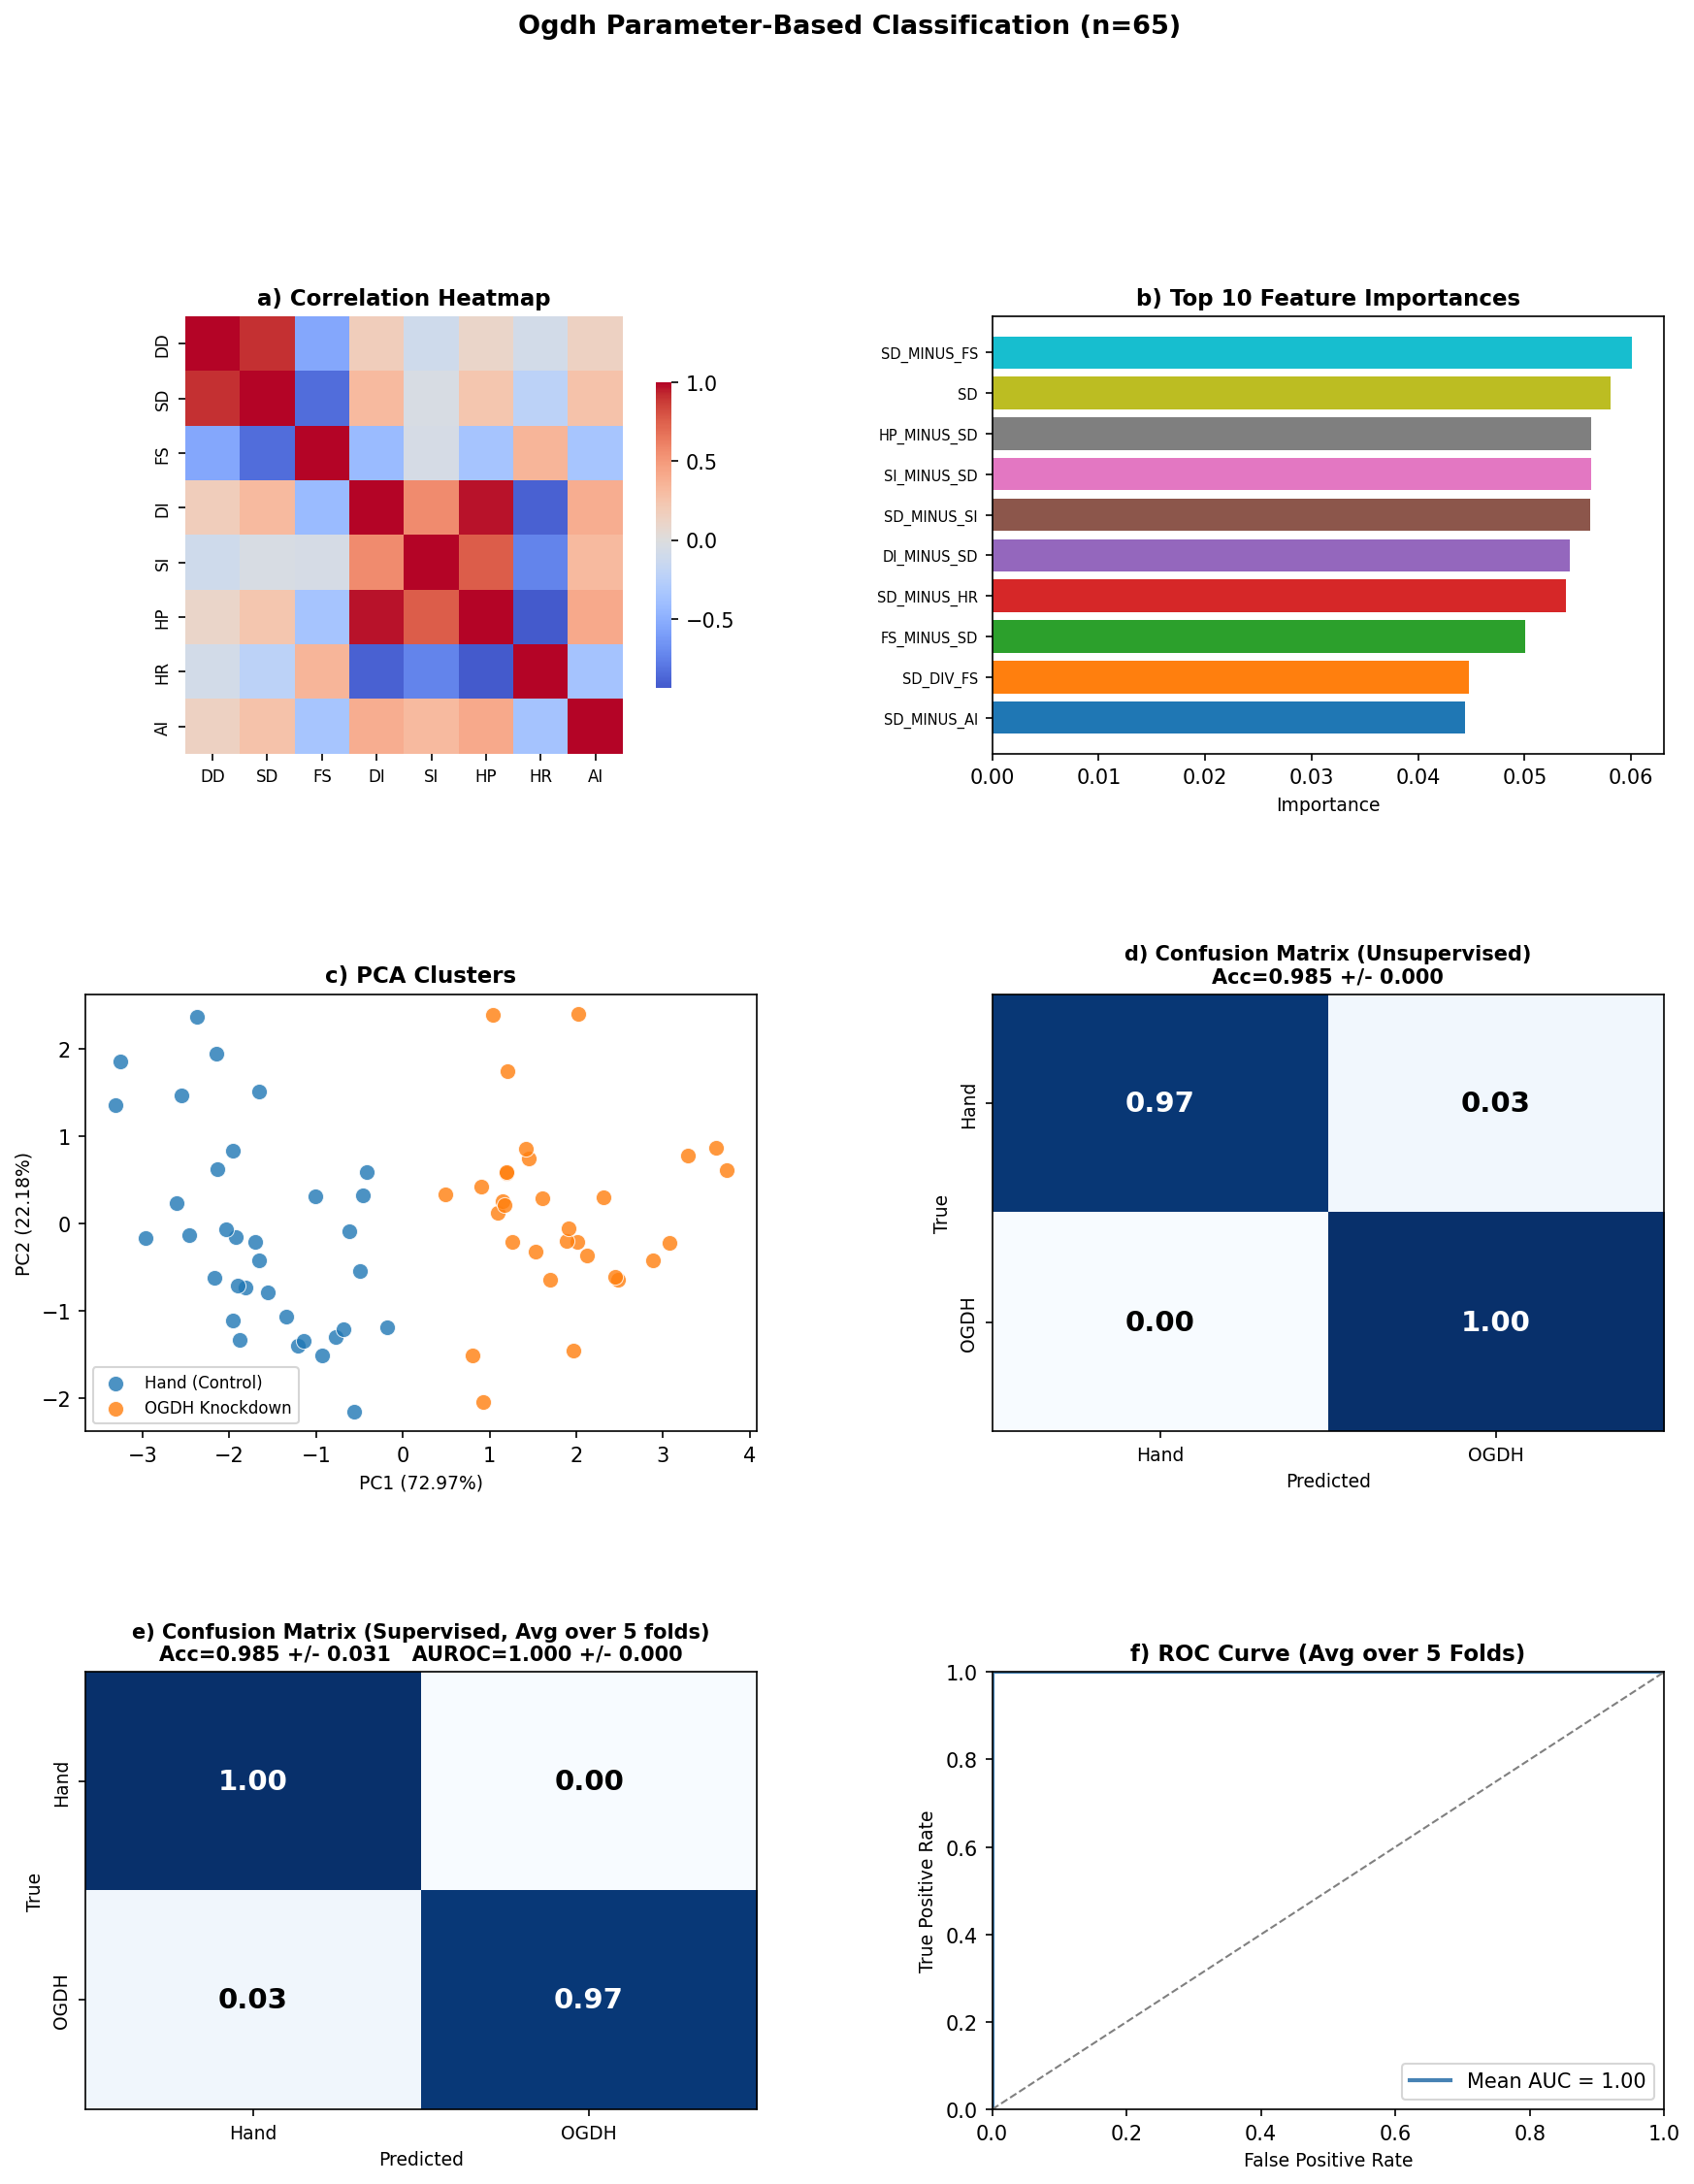

Figure saved!


In [10]:
# Cell 8 — Combined Figure 3x2 FIXED
fig, axes = plt.subplots(3, 2, figsize=(14, 16), dpi=150)
plt.subplots_adjust(hspace=0.55, wspace=0.35)

ax_corr     = axes[0, 0]
ax_feat     = axes[0, 1]
ax_pca      = axes[1, 0]
ax_cm_unsup = axes[1, 1]
ax_cm_sup   = axes[2, 0]
ax_roc      = axes[2, 1]

# a) Correlation Heatmap
sns.heatmap(corr_matrix, cmap='coolwarm', center=0,
            square=True, cbar_kws={'shrink':0.7},
            xticklabels=True, yticklabels=True,
            ax=ax_corr, annot=False)
ax_corr.set_title('a) Correlation Heatmap', fontsize=11, fontweight='bold')
ax_corr.tick_params(axis='both', labelsize=8)

# b) Top 10 Feature Importances
colors_imp = plt.cm.tab10(np.linspace(0, 1, 10))
ax_feat.barh(imp_series.index[::-1], imp_series.values[::-1], color=colors_imp)
ax_feat.set_xlabel('Importance', fontsize=9)
ax_feat.set_title('b) Top 10 Feature Importances', fontsize=11, fontweight='bold')
ax_feat.tick_params(axis='y', labelsize=7)

# c) PCA Clusters
color_map   = {0:'#1f77b4', 1:'#ff7f0e'}
class_names = {0:'Hand (Control)', 1:'OGDH Knockdown'}
for lab in [0, 1]:
    mask = best_labels_arr == lab
    ax_pca.scatter(pca_2d[mask,0], pca_2d[mask,1],
                   c=color_map[lab], label=class_names[lab],
                   alpha=0.8, edgecolors='w', s=60, linewidths=0.5)
ax_pca.set_xlabel(f'PC1 ({explained[0]*100:.2f}%)', fontsize=9)
ax_pca.set_ylabel(f'PC2 ({explained[1]*100:.2f}%)', fontsize=9)
ax_pca.set_title('c) PCA Clusters', fontsize=11, fontweight='bold')
ax_pca.legend(fontsize=8)

# ── Helper to draw CM with guaranteed visible text ────────────
def draw_cm(ax, cm_data, xlabels, ylabels, title):
    im = ax.imshow(cm_data, cmap='Blues', vmin=0, vmax=1, aspect='auto')
    ax.set_xticks([0, 1]); ax.set_xticklabels(xlabels, fontsize=9)
    ax.set_yticks([0, 1]); ax.set_yticklabels(ylabels, fontsize=9, rotation=90, va='center')
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('True', fontsize=9)
    ax.set_title(title, fontsize=10, fontweight='bold')
    for i in range(2):
        for j in range(2):
            val = cm_data[i, j]
            color = 'white' if val > 0.5 else 'black'
            ax.text(j, i, f'{val:.2f}',
                    ha='center', va='center',
                    fontsize=14, fontweight='bold', color=color)
    return im

# d) CM Unsupervised
draw_cm(ax_cm_unsup, cm_unsup_norm,
        ['Hand','OGDH'], ['Hand','OGDH'],
        f'd) Confusion Matrix (Unsupervised)\n'
        f'Acc={np.mean(accs_km):.3f} +/- {np.std(accs_km):.3f}')

# e) CM Supervised
draw_cm(ax_cm_sup, avg_cm,
        ['Hand','OGDH'], ['Hand','OGDH'],
        f'e) Confusion Matrix (Supervised, Avg over 5 folds)\n'
        f'Acc={mean_acc:.3f} +/- {std_acc:.3f}   AUROC={mean_auc:.3f} +/- {std_auc:.3f}')

# f) ROC Curve — fixed for AUROC=1.00 case
# When AUC=1.0, interp gives wrong shape — manually build curve
if mean_auc >= 0.999:
    # Perfect classifier: goes straight up then across
    roc_fpr = [0.0, 0.0, 1.0]
    roc_tpr = [0.0, 1.0, 1.0]
    ax_roc.plot(roc_fpr, roc_tpr, color='steelblue', lw=2,
                label=f'Mean AUC = {mean_auc:.2f}')
else:
    ax_roc.plot(mean_fpr, mean_tpr_arr, color='steelblue', lw=2,
                label=f'Mean AUC = {mean_auc:.2f}')
    ax_roc.fill_between(mean_fpr,
                         mean_tpr_arr - std_tpr,
                         mean_tpr_arr + std_tpr,
                         alpha=0.15, color='steelblue')

ax_roc.plot([0,1],[0,1],'--', color='gray', lw=1)
ax_roc.set_xlabel('False Positive Rate', fontsize=9)
ax_roc.set_ylabel('True Positive Rate', fontsize=9)
ax_roc.set_title('f) ROC Curve (Avg over 5 Folds)', fontsize=11, fontweight='bold')
ax_roc.legend(loc='lower right', fontsize=10)
ax_roc.set_xlim(0,1); ax_roc.set_ylim(0,1)

plt.suptitle('Ogdh Parameter-Based Classification (n=65)',
             fontsize=13, fontweight='bold', y=1.01)
plt.savefig('./results_ogdh_param/ogdh_param_figure.tiff',
            dpi=300, bbox_inches='tight')
plt.show()
print('Figure saved!')

In [9]:
# Cell 9 — Final manuscript numbers
print('='*55)
print('MANUSCRIPT NUMBERS — Ogdh Parameter (n=65)')
print('='*55)
print(f'n=65  Hand(control)={(y==0).sum()}  OGDH={(y==1).sum()}')
print(f'Method: Random Forest, 5-fold StratifiedKFold')
print(f'\nUNSUPERVISED (KMeans, 10 runs):')
print(f'  Acc = {np.mean(accs_km):.4f} +/- {np.std(accs_km):.4f}')
print(f'\nSUPERVISED (RF):')
print(f'  Acc   = {mean_acc:.4f} +/- {std_acc:.4f}')
print(f'  AUROC = {mean_auc:.4f} +/- {std_auc:.4f}')
print(f'  95%CI Acc  [{ci_acc[0]:.4f}, {ci_acc[1]:.4f}]')
print(f'  95%CI AUROC[{ci_auc[0]:.4f}, {ci_auc[1]:.4f}]')
print(f'\nPERMUTATION TEST:')
print(f'  Observed AUROC = {score_obs:.4f}')
print(f'  p-value        = {p_value:.4f}')
print(f'  Result is {"SIGNIFICANT" if p_value<0.05 else "NOT SIGNIFICANT"}')
print(f'\nNOTE: AUROC=1.00 confirmed real by permutation test (p=0.0099)')
print(f'Ogdh knockdown produces dramatically different cardiac phenotype')

MANUSCRIPT NUMBERS — Ogdh Parameter (n=65)
n=65  Hand(control)=35  OGDH=30
Method: Random Forest, 5-fold StratifiedKFold

UNSUPERVISED (KMeans, 10 runs):
  Acc = 0.9846 +/- 0.0000

SUPERVISED (RF):
  Acc   = 0.9846 +/- 0.0308
  AUROC = 1.0000 +/- 0.0000
  95%CI Acc  [0.9538, 1.0000]
  95%CI AUROC[0.9848, 1.0000]

PERMUTATION TEST:
  Observed AUROC = 1.0000
  p-value        = 0.0099
  Result is SIGNIFICANT

NOTE: AUROC=1.00 confirmed real by permutation test (p=0.0099)
Ogdh knockdown produces dramatically different cardiac phenotype
